# Building a deep neural network from scratch for handwritten digit recognition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Math functions

1) One Hot encoder [len(labels) is the batch size] 

In [17]:
def one_hot(labels):
    y_true = np.zeros([10, len(labels)])
    for i in range(len(labels)):
        y_true[labels[i], i] = 1
    return y_true # size is 10 x batch_size

print(one_hot([3,0,2,7]))

[[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


2) ReLU activation and derivative

In [18]:
def relu(z):
    return (np.maximum(0, z))


def relu_derivative(z):
    return (z > 0).astype(float) # Converts True to 1. and False to 0. which are ReLu derivatives

3. Softmax activation

In [19]:
def softmax(z):
    
    # subtract max of z for numerical stability and prevent overflow. This does not change the output as the constant cancels in the numerator and denominator.

    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)   # sum over columns for normalization

4. Forward Pass for a two layer network

In [20]:
def forward_pass(x0, w1, b1, w2, b2):

    # x0 is input pixel batch with shape (784 x batch_size)
    # w1 is layer 1 weights with shape ({output layer size} x 784 {input layer size})
    # b1 is layer 1 bias with shape (10 x 1) as the same bias is added to every column of the batch
    # z1 is pre-activation output for layer 1 with shape (10 x batch_size)
    z1 = w1 @ x0+b1

    # x1 is post-activation output for layer 1 with shape (10 x batch_size)
    x1 = relu(z1)

    # w2 is layer 2 weights with shape (10 {output layer size} x 10 {input layer size})
    # b2 is layer 2 bias with shape (10 x 1)
    # z2 is pre-activation output for layer 2 with shape (10 x batch_size)
    z2 = w2 @ x1+b2

    # x2 is post-activation output for layer 1 with shape (10 x batch_size)
    x2 = softmax(z2)

    return z1, x1, x2

5. Back propagation function

In [21]:
def back_prop(batch_size, x0, z1, x1, x2, y0, w2):

    # boundary error vector with shape (10 x batch_size)
    eps2 = x2 - y0

    # layer 2 weight gradient averaged over batch with shape (10 x batch_size) x (batch_size x 10) = (10 x 10), same as w2
    dL_w2 = (1/batch_size) * (eps2 @ x1.T)

    # layer 2 bias gradient averaged over batch with shape (10, 1), same as b2
    dL_b2 = (1/batch_size) * np.sum(eps2, axis=1, keepdims=True)

    # Hidden layer error vector with shape (10 x bach_size). Note the element-wise multtiplication with relu_derivative
    eps1 = (w2.T @ eps2) * relu_derivative(z1)

    # layer 1 weight gradient averaged over batch with shape (10 x 784)
    dL_w1 = (1/batch_size) * (eps1 @ x0.T)

    # layer 1 bias gradient averaged over batch with shape (10 x 1)
    dL_b1 = (1/batch_size) * np.sum(eps1, axis=1, keepdims=True)

    return dL_w1, dL_b1, dL_w2, dL_b2

6. Update function which updates the weights and biases using gradient descent

In [22]:
def update_params(alpha, w1, dL_w1, b1, dL_b1, w2, dL_w2, b2, dL_b2):

    # alpha is learning rate 
    w1 = w1 - alpha * dL_w1
    b1 = b1 - alpha * dL_b1
    w2 = w2 - alpha * dL_w2
    b2 = b2 - alpha * dL_b2

    return w1, b1, w2, b2

# Evaluation function

A function to test the performance of the model based on how many labels it gets correct

In [23]:
def accuracy(y_pred, y_true_labels):

    y_pred_labels = np.argmax(y_pred, axis=0) # converts the on-hot encoded column to labels

    return int(100 * np.sum( y_pred_labels == y_true_labels ) / y_true_labels.size)

# Loading data and model initialisation

1. Data is from MNIST and has 784 columns for each pixel grayscale value. It has 42000 rows which are the 42000 handwritten number examples. 

2. We will also divide our data into training sample of say 40000 digits and a testing sample of 2000 digits. While training, the model will never see the testing data.

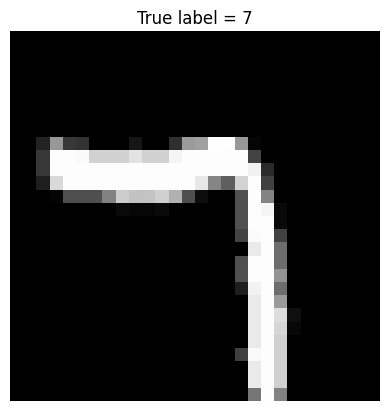

In [13]:
df = pd.read_csv('data.csv')

labels = df['label'].values
features = df.drop('label', axis=1)
features = (features.values / 255.0).T # normalise pixel values to range 0 to 1

# visualising the data

random_img = np.random.randint(42000)
true_label = labels[random_img]
img = features[:, random_img].reshape(28, 28)
plt.imshow(img, cmap='gray');
plt.title(f'True label = {true_label}')
plt.axis('off');

# divide data into training and testing samples

training_features = features[:, 0:40000]
training_labels = labels[0:40000]

testing_features = features[:,40000:]
testing_labels = labels[40000:]

# Model initialisation

Our model is essentially just weights and biases. These will be randomly initialised and then training the model will optimise the weights and biases. 

In [14]:
# initialising the model with random weights and biases

w1 = np.random.uniform(-0.5, 0.5, (10, 784))
b1 = np.random.uniform(-0.5, 0.5, (10, 1))
w2 = np.random.uniform(-0.5, 0.5, (10, 10))
b2 = np.random.uniform(-0.5, 0.5, (10, 1))

# Training loop

1. Now we define a function to train the model, as in update the weights and gradients such that the model is able to predict the label of the handwritten digit
2. The model will be trained for a fixed number of iterations, called epochs
3. We would also need to set the $\alpha$ parameter (learning-rate or step size to update gradients)
4. Finally we must decide the batch size. Updating the gradient for every handwritten digit is technically the best way to optimize, but might lead to overfitting and is also computationally expensive. We don't want the model to learn the labels of exact digits as it will then perform poorly on unseen digits. We want it to learn the underlying patterns that link the digit shapes to its label 
5. Once training is complete, a forward pass of the model should give the correctly recognised digit

In [39]:
def train_model(w1, b1, w2, b2, epochs, learning_rate, batch_size):

    for epoch in range(epochs):

        # shuffling data helps avoid overfitting and 'memorzing' the data

        idx = np.random.permutation(training_features.shape[1])
        shuffled_features = training_features[:, idx]
        shuffled_labels = training_labels[idx]

        # we need to divide our 40000 test data into batches based on input batch_size
        set_number = 0
        
        while set_number + batch_size <= 40000:

            batch_x = shuffled_features[:, set_number:set_number + batch_size]    # (784, batch_size)
            batch_y_labels = shuffled_labels[set_number:set_number + batch_size]  # (batch_size,)
            batch_y = one_hot(batch_y_labels)                         # (10, batch_size)

            # forward pass
            z1, x1, x2 = forward_pass(batch_x, w1, b1, w2, b2)

            # back-propagation
            dL_w1, dL_b1, dL_w2, dL_b2 = back_prop(batch_size, batch_x, z1, x1, x2, batch_y, w2)

            # gradient descent update
            w1, b1, w2, b2 = update_params(learning_rate, w1, dL_w1, b1, dL_b1, w2, dL_w2, b2, dL_b2)

            set_number += batch_size

        # print accuracy after each epoch

        _, _, x2_train = forward_pass(training_features, w1, b1, w2, b2)
        _, _, x2_test  = forward_pass(testing_features,  w1, b1, w2, b2)

        print(f'Iteration: {epoch+1:>3d} | Training accuracy: {accuracy(x2_train, training_labels)}% | Testing accuracy: {accuracy(x2_test, testing_labels)}%')

    return w1, b1, w2, b2

w1, b1, w2, b2 = train_model(w1, b1, w2, b2, 100, 0.01, 100)

Iteration:   1 | Training accuracy: 32% | Testing accuracy: 31%
Iteration:   2 | Training accuracy: 49% | Testing accuracy: 49%
Iteration:   3 | Training accuracy: 61% | Testing accuracy: 62%
Iteration:   4 | Training accuracy: 69% | Testing accuracy: 69%
Iteration:   5 | Training accuracy: 73% | Testing accuracy: 73%
Iteration:   6 | Training accuracy: 76% | Testing accuracy: 76%
Iteration:   7 | Training accuracy: 78% | Testing accuracy: 78%
Iteration:   8 | Training accuracy: 80% | Testing accuracy: 80%
Iteration:   9 | Training accuracy: 81% | Testing accuracy: 80%
Iteration:  10 | Training accuracy: 82% | Testing accuracy: 81%
Iteration:  11 | Training accuracy: 83% | Testing accuracy: 82%
Iteration:  12 | Training accuracy: 83% | Testing accuracy: 82%
Iteration:  13 | Training accuracy: 84% | Testing accuracy: 83%
Iteration:  14 | Training accuracy: 84% | Testing accuracy: 84%
Iteration:  15 | Training accuracy: 85% | Testing accuracy: 84%
Iteration:  16 | Training accuracy: 85% 

# Save the model

Our trained model can be reused later, so let's save the weights and bisases

In [53]:
np.savez('scratch_model.npz', w1=w1, b1=b1, w2=w2, b2=b2)

# See how it performs

The model never saw the testing data, so let's see how it performs for a bunch of images. In regression terms, we're extrapolating. 

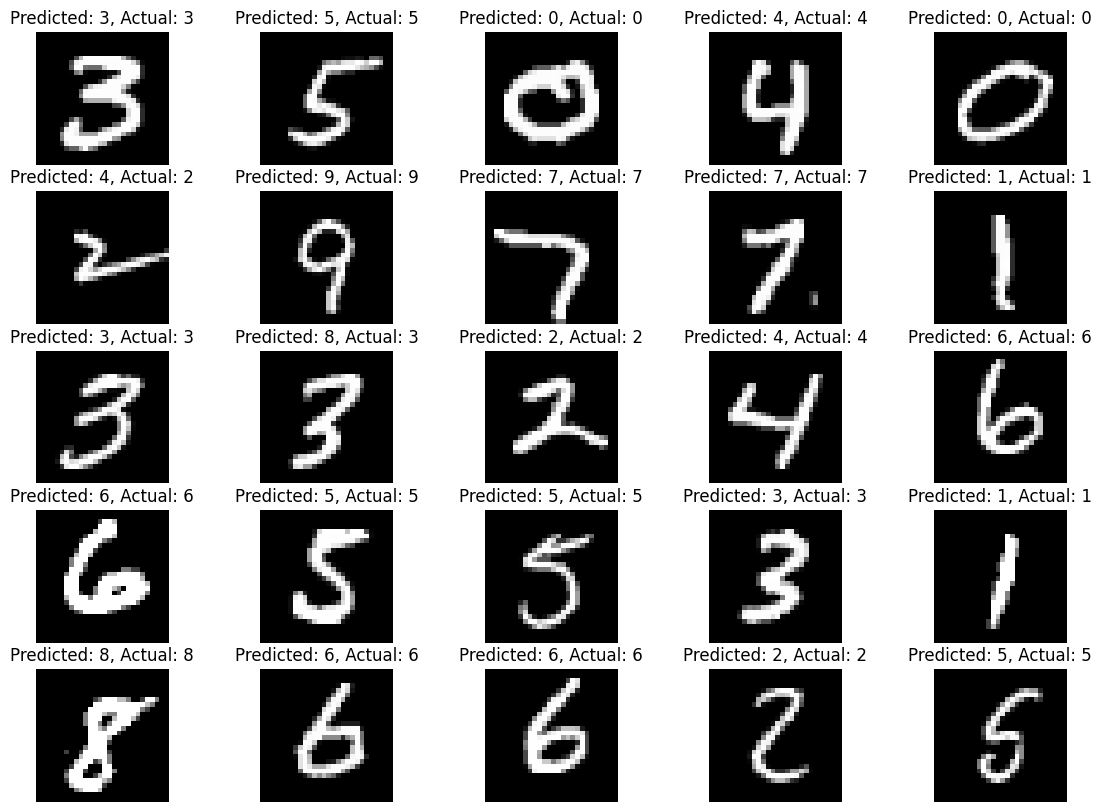

In [64]:
# load the model
model = np.load('scratch_model.npz')
w1 = model['w1']
b1 = model['b1']
w2 = model['w2']
b2 = model['b2']

fig, axes = plt.subplots(5, 5, figsize=(14, 10))

for ax in axes.ravel():

    n = np.random.randint(40000, 42000)

    digit = features[:, n].reshape(-1, 1)
    label = labels[n]

    # forward pass
    z1, x1, x2 = forward_pass(digit, w1, b1, w2, b2)
    prediction = np.argmax(x2)

    # display
    digit = features[:, n].reshape(28, 28)
    ax.imshow(digit, cmap='gray')
    ax.set_title(f"Predicted: {prediction}, Actual: {label}")
    ax.axis('off')